In [89]:
import pandas as pd
import numpy as np
from pathlib import Path

In [90]:
DATA = Path("../data")

In [91]:
tickets = pd.read_csv(DATA / "tickets.csv")

In [92]:
tickets.head()

,ticket_id,created_at,first_response_at,resolved_at,status,channel,customer_id,order_id,product_sku,category,...,assigned_team,agent_id,transfers,csat_score,refund_amount_inr,refund_reason_code,replacement_issued,customer_message,agent_notes,source_system
0,TK-240001,2025-01-01 06:12,2025-01-01 06:20,2025-01-02 06:33,resolved,voice,C102873,NaN,VA-EB-AIR,Billing & Payments,...,Billing,A3033,0,3.0,764.0,RETURN-QC-OK,N,[IVR transcript] you picked up the item 4 days...,re: refund pending | chk reverse pickup qc sta...,legacy_fd
1,TK-240002,2025-01-01 09:01,2025-01-01 09:34,2025-01-01 09:45,resolved,social,C103321,NaN,VA-HP-ST3,Other,...,Chat Frontline,A3015,0,0.0,NaN,NaN,N,product: my strata 3 headphones\norder: vr8959...,Reported: promo code invalid. Checked coupon v...,legacy_fd
2,TK-240004,2025-01-02 00:41,2025-01-02 03:41,2025-01-04 03:59,resolved,email,C100687,VR895382,VA-EB-PL1,Delivery & Shipping,...,Logistics,A3028,0,4.0,NaN,NaN,N,"hi there,\norder vr895382 (my pulse). i haven'...",Cust contacted re order not delivered. Confiir...,legacy_fd
3,TK-240006,2025-01-02 02:21,2025-01-02 03:38,2025-01-12 04:37,resolved,social,C104148,NaN,VA-EB-PL1,Audio Quality,...,Chat Frontline,A3044,1,3.0,NaN,NaN,N,honestly regretting this purchase. bought the ...,1. Audio distortion\n2. Asked for a recording\...,legacy_fd
4,TK-240007,2025-01-02 04:05,2025-01-02 04:38,2025-01-02 05:09,resolved,social,C103733,VR883581,VA-EB-PL1,Billing & Payments,...,Billing,A3035,0,0.0,NaN,NaN,N,"paid via UPI, amount deducted, no order confir...",cx: amount deducted without order | asked for ...,legacy_fd


In [93]:
tickets.shape

(11816, 21)

In [94]:
tickets["ticket_id"].nunique()

11200

In [95]:
tickets["ticket_id"].duplicated().sum()

np.int64(616)

In [96]:
dup_rows = tickets[tickets["ticket_id"].duplicated(keep=False)]

dup_rows[["ticket_id", "source_system", "csat_score"]].sort_values("ticket_id").head(20)

,ticket_id,source_system,csat_score
12,TK-240016,helpdesk,NaN
13,TK-240016,legacy_fd,0.0
15,TK-240018,helpdesk,NaN
16,TK-240018,legacy_fd,0.0
19,TK-240021,helpdesk,NaN
20,TK-240021,legacy_fd,0.0
23,TK-240025,helpdesk,NaN
24,TK-240025,legacy_fd,0.0
30,TK-240030,legacy_fd,0.0
29,TK-240030,helpdesk,NaN


This asks:

“For each row, does this ticket_id appear more than once?”

keep=False is important: both copies are considered. Then keep only those duplicate rows

In [97]:
len(dup_rows) # 1232 is the output: as both the first copy and its duplicate are considered (616 + 616)

1232

#### Inspect one duplicate closely

In [98]:
sample_id = dup_rows["ticket_id"].iloc[0]

tickets[tickets["ticket_id"] == sample_id].T # .T transposes the table so the fields become rows. Much easier to inspect.

,12,13
ticket_id,TK-240016,TK-240016
created_at,2025-01-03 03:38,2025-01-03 03:38
first_response_at,2025-01-03 03:57,2025-01-03 03:57
resolved_at,2025-01-03 04:25,2025-01-03 04:25
status,resolved,resolved
channel,voice,voice
customer_id,C103315,C103315
order_id,NaN,NaN
product_sku,VA-AC-CH65,VA-AC-CH65
category,Other,Other


##### Closely inspecting the duplicates shows us that they are exactly same in all attributes except 2: 

source_system & csat_score

* csat_score: [NaN, 0.0]
* source_system: [helpdesk, legacy_fd]

The email data and policy explicitly says the current helpdesk went live on 14 Sep 2025 and that legacy tickets were re-imported during reconciliation. Therefore for a case of duplicacy - Given that the helpdesk copy has the normal CSAT representation while the legacy copy can use 0 for no response, the natural canonical choice is:

Keep the helpdesk copy.

#### Code check of whether the duplicates differ in any other volumns or not

In [99]:
compare_cols = [
    c for c in tickets.columns
    if c not in ["source_system", "csat_score"]
]

# We check if the duplicates are identical in all other columns except the 2 listed columns
pair = tickets[tickets["ticket_id"] == sample_id]
same = (
    pair.iloc[0][compare_cols].eq(pair.iloc[1][compare_cols])
    |
    (pair.iloc[0][compare_cols].isna() &
     pair.iloc[1][compare_cols].isna())
)

same.all()

np.True_

In [100]:
dup_rows.groupby("source_system")["ticket_id"].nunique()

source_system
helpdesk     616
legacy_fd    616
Name: ticket_id, dtype: int64

#### Deduplication

Now we need to implement the canonical rule:

For duplicated ticket_ids, retain the helpdesk record

In [101]:
tickets_clean = tickets.copy()

In [102]:
tickets_clean["source_system"].value_counts()

source_system
helpdesk     8079
legacy_fd    3737
Name: count, dtype: int64

In [103]:
# We keep the helpdesk record and remove the legacy_fd one
source_priority = {
    "helpdesk": 0,
    "legacy_fd": 1
}

tickets_clean["_source_priority"] = (
    tickets_clean["source_system"].map(source_priority)
)

In [104]:
tickets_clean = tickets_clean.sort_values(
    ["ticket_id", "_source_priority"]
)

In [105]:
tickets_clean = tickets_clean.drop_duplicates(
    subset="ticket_id",
    keep="first"
)

In [106]:
tickets_clean = tickets_clean.drop(
    columns="_source_priority"
).reset_index(drop=True)

In [107]:
print("Raw rows:", len(tickets))
print("Clean rows:", len(tickets_clean))
print("Unique ticket IDs:", tickets_clean["ticket_id"].nunique())

Raw rows: 11816
Clean rows: 11200
Unique ticket IDs: 11200


In [108]:
if (tickets_clean["ticket_id"].is_unique)==True:
    print("Deduplication successful !!")

Deduplication successful !!


#### Check for Missing Values

But here for missing values we shall neither drop or impute them, since missing vlaues are significantly different and means a different aspect

A missing value for different column might contain:

| Column | Missing means | Action |
|----------|---------------------------|----------------------------------------------|
| `order_id` | Customer didn't provide it | Leave missing |
| `resolved_at` | Ticket unresolved/pending | Leave missing |
| `refund_amount_inr` | No refund | Likely interpret as ₹0 only when doing refund arithmetic |
| `refund_reason_code` | No refund | Leave missing |
| `csat_score` | No response | Exclude from CSAT calculation |


We do not impute missing values globally. We interpret them according to the business meaning of each field.

In [109]:
tickets_clean.isna().sum()

ticket_id                0
created_at               0
first_response_at        0
resolved_at            589
status                   0
channel                  0
customer_id              0
order_id              3840
product_sku              0
category                 0
priority                 0
assigned_team            0
agent_id                 0
transfers                0
csat_score            4477
refund_amount_inr     9222
refund_reason_code    9222
replacement_issued       0
customer_message         0
agent_notes              0
source_system            0
dtype: int64

In [110]:
tickets_clean.isna().mean().mul(100).round(2)

ticket_id              0.00
created_at             0.00
first_response_at      0.00
resolved_at            5.26
status                 0.00
channel                0.00
customer_id            0.00
order_id              34.29
product_sku            0.00
category               0.00
priority               0.00
assigned_team          0.00
agent_id               0.00
transfers              0.00
csat_score            39.97
refund_amount_inr     82.34
refund_reason_code    82.34
replacement_issued     0.00
customer_message       0.00
agent_notes            0.00
source_system          0.00
dtype: float64

#### Next Challenge to Address

This is the next critical issue because:

1. CSV timestamps = UTC
2. shifts = IST
3. SLA is measured from ticket creation to first human response
4. weekly reporting needs the operational local date/week

The policy confirms the API exports UTC while the helpdesk's standard reports/shifts are IST.

In [111]:
tickets_clean[["created_at", "first_response_at"]].dtypes

created_at           str
first_response_at    str
dtype: object

Converting the str object into date-tie format

In [112]:
tickets_clean["created_at"] = pd.to_datetime(
    tickets_clean["created_at"],
    utc=True
)

tickets_clean["first_response_at"] = pd.to_datetime(
    tickets_clean["first_response_at"],
    utc=True
)

**NOTE**

Converting this into pandas datetime object considers them as UTC (utc=True). Later for uniformity we need to convert these into IST.

In [113]:
tickets_clean[["created_at", "first_response_at"]].head()

,created_at,first_response_at
0,2025-01-01 06:12:00+00:00,2025-01-01 06:20:00+00:00
1,2025-01-01 09:01:00+00:00,2025-01-01 09:34:00+00:00
2,2025-01-02 00:41:00+00:00,2025-01-02 03:41:00+00:00
3,2025-01-02 02:21:00+00:00,2025-01-02 03:38:00+00:00
4,2025-01-02 04:05:00+00:00,2025-01-02 04:38:00+00:00


In [114]:
tickets_clean[["created_at", "first_response_at"]].dtypes

created_at           datetime64[us, UTC]
first_response_at    datetime64[us, UTC]
dtype: object

We don't overwrite UTC column rather create a new one

In [115]:
tickets_clean["created_at_ist"] = (
    tickets_clean["created_at"].dt.tz_convert("Asia/Kolkata")
)

tickets_clean["first_response_at_ist"] = (
    tickets_clean["first_response_at"].dt.tz_convert("Asia/Kolkata")
)

In [116]:
tickets_clean[
    ["created_at", "created_at_ist",
     "first_response_at", "first_response_at_ist"]
].head()

,created_at,created_at_ist,first_response_at,first_response_at_ist
0,2025-01-01 06:12:00+00:00,2025-01-01 11:42:00+05:30,2025-01-01 06:20:00+00:00,2025-01-01 11:50:00+05:30
1,2025-01-01 09:01:00+00:00,2025-01-01 14:31:00+05:30,2025-01-01 09:34:00+00:00,2025-01-01 15:04:00+05:30
2,2025-01-02 00:41:00+00:00,2025-01-02 06:11:00+05:30,2025-01-02 03:41:00+00:00,2025-01-02 09:11:00+05:30
3,2025-01-02 02:21:00+00:00,2025-01-02 07:51:00+05:30,2025-01-02 03:38:00+00:00,2025-01-02 09:08:00+05:30
4,2025-01-02 04:05:00+00:00,2025-01-02 09:35:00+05:30,2025-01-02 04:38:00+00:00,2025-01-02 10:08:00+05:30


Calculate Response Duration

In [117]:
tickets_clean["response_time"] = (
    tickets_clean["first_response_at"]
    - tickets_clean["created_at"]
)

In [118]:
tickets_clean["response_minutes"] = (
    tickets_clean["response_time"].dt.total_seconds() / 60
)

In [119]:
tickets_clean["response_minutes"].describe()

count    11200.000000
mean       155.174643
std        229.881160
min          0.000000
25%          7.000000
50%         51.000000
75%        241.000000
max       5155.000000
Name: response_minutes, dtype: float64

Apply the actual SLA policy

In [120]:
sla_minutes = {
    "chat": 15,
    "voice": 120,
    "social": 240,
    "email": 480
}

tickets_clean["sla_target_minutes"] = (
    tickets_clean["channel"].map(sla_minutes)
)

tickets_clean[
    ["channel", "sla_target_minutes"]
].drop_duplicates().sort_values("channel")

,channel,sla_target_minutes
7,chat,15
2,email,480
1,social,240
0,voice,120


Calculate Breach

In [121]:
tickets_clean["breach"] = (
    tickets_clean["response_minutes"]
    > tickets_clean["sla_target_minutes"]
)

tickets_clean["breach"].value_counts()

breach
False    8760
True     2440
Name: count, dtype: int64

In [122]:
tickets_clean["breach"].mean()

np.float64(0.21785714285714286)

#### Validation

For each channel, how many tickets met/missed SLA?

In [123]:
pd.crosstab(
    tickets_clean["channel"],
    tickets_clean["breach"]
)

breach,False,True
channel,,
chat,3591,1368
email,2902,745
social,863,243
voice,1404,84


In [124]:
tickets_clean.groupby("channel")["response_minutes"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
channel,,,,
chat,4959,85.151240,6.0,552.0
email,3647,295.752399,216.0,5155.0
social,1106,152.216998,84.0,920.0
voice,1488,46.189516,34.0,413.0


#### Here we add the Roster data - Roster Mapping

In [125]:
agents = pd.read_csv(DATA / "agents.csv")

In [126]:
agents.head()

,agent_id,name,site,team,shift,tier,from_date,to_date
0,A3001,Zoya Mehta,Indore,Chat Frontline,Night,1,2021-04-20,2025-06-29
1,A3002,Tarun Mishra,Indore,Chat Frontline,Night,1,2023-02-12,2025-06-29
2,A3002,Tarun Mishra,Indore,Chat Frontline,Day,1,2025-06-30,NaN
3,A3003,Harpreet Deshpande,Indore,Chat Frontline,Night,1,2023-06-14,2025-06-29
4,A3003,Harpreet Deshpande,Indore,Chat Frontline,Day,1,2025-06-30,NaN


In [127]:
agents.columns

Index(['agent_id', 'name', 'site', 'team', 'shift', 'tier', 'from_date',
       'to_date'],
      dtype='str')

In [128]:
agents[["agent_id", "site", "team", "shift", "tier",
        "from_date", "to_date"]][:5]

,agent_id,site,team,shift,tier,from_date,to_date
0,A3001,Indore,Chat Frontline,Night,1,2021-04-20,2025-06-29
1,A3002,Indore,Chat Frontline,Night,1,2023-02-12,2025-06-29
2,A3002,Indore,Chat Frontline,Day,1,2025-06-30,NaN
3,A3003,Indore,Chat Frontline,Night,1,2023-06-14,2025-06-29
4,A3003,Indore,Chat Frontline,Day,1,2025-06-30,NaN


Now to perform a join of the roster data we need to extract the agent_id from tickets.csv on which we shall join..But agent_id alone isn't enough because an agent can change assignment.

So we need:

agent_id+date→site, shift, team, tier

This is therefore a temporal raster join

#### NOTE

One important decision before the join

Because the policy says: "breaches are reported against the resolving agent."

our roster lookup should use:

agent_id
+
resolved_at

for resolved/closed tickets.

Not:

created_at

because the ticket may have been created before the eventual resolver's assignment.

In [129]:
agents["from_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [130]:
agents["from_date"] = pd.to_datetime(agents["from_date"])
agents["to_date"] = pd.to_datetime(agents["to_date"])

agents[
    ["agent_id", "site", "team", "shift", "tier",
     "from_date", "to_date"]
].sort_values(["agent_id", "from_date"])

,agent_id,site,team,shift,tier,from_date,to_date
0,A3001,Indore,Chat Frontline,Night,1,2021-04-20,2025-06-29
1,A3002,Indore,Chat Frontline,Night,1,2023-02-12,2025-06-29
2,A3002,Indore,Chat Frontline,Day,1,2025-06-30,NaT
3,A3003,Indore,Chat Frontline,Night,1,2023-06-14,2025-06-29
4,A3003,Indore,Chat Frontline,Day,1,2025-06-30,NaT
5,A3004,Bengaluru,Chat Frontline,Day,1,2022-12-30,NaT
6,A3005,Bengaluru,Chat Frontline,Morning,1,2021-07-28,NaT
7,A3006,Bengaluru,Chat Frontline,Day,1,2021-02-05,NaT
8,A3007,Bengaluru,Chat Frontline,Morning,1,2023-09-10,NaT
9,A3008,Indore,Chat Frontline,Morning,1,2022-05-02,NaT


In [131]:
agents["to_date"].dtype

dtype('<M8[us]')

In [132]:
tickets_clean.columns

Index(['ticket_id', 'created_at', 'first_response_at', 'resolved_at', 'status',
       'channel', 'customer_id', 'order_id', 'product_sku', 'category',
       'priority', 'assigned_team', 'agent_id', 'transfers', 'csat_score',
       'refund_amount_inr', 'refund_reason_code', 'replacement_issued',
       'customer_message', 'agent_notes', 'source_system', 'created_at_ist',
       'first_response_at_ist', 'response_time', 'response_minutes',
       'sla_target_minutes', 'breach'],
      dtype='str')

In [133]:
tickets_clean["resolved_at"]

0        2025-01-02 06:33
1        2025-01-01 09:45
2        2025-01-04 03:59
3        2025-01-12 04:37
4        2025-01-02 05:09
               ...       
11195    2026-06-30 11:25
11196    2026-07-04 04:52
11197                 NaN
11198    2026-06-30 16:08
11199    2026-06-30 16:17
Name: resolved_at, Length: 11200, dtype: str

In [134]:
tickets_clean["resolved_at_utc"] = pd.to_datetime(
    tickets_clean["resolved_at"],
    utc=True
)

In [135]:
tickets_clean["resolved_at_utc"].dtype

datetime64[us, UTC]

In [136]:
tickets_clean["resolved_at_ist"] = (
    tickets_clean["resolved_at_utc"]
    .dt.tz_convert("Asia/Kolkata")
)

In [137]:
tickets_clean[
    ["ticket_id", "agent_id", "resolved_at", "resolved_at_ist", "status"]
].head()

,ticket_id,agent_id,resolved_at,resolved_at_ist,status
0,TK-240001,A3033,2025-01-02 06:33,2025-01-02 12:03:00+05:30,resolved
1,TK-240002,A3015,2025-01-01 09:45,2025-01-01 15:15:00+05:30,resolved
2,TK-240004,A3028,2025-01-04 03:59,2025-01-04 09:29:00+05:30,resolved
3,TK-240006,A3044,2025-01-12 04:37,2025-01-12 10:07:00+05:30,resolved
4,TK-240007,A3035,2025-01-02 05:09,2025-01-02 10:39:00+05:30,resolved


Why are we using resolved_at?

Because the policy explicitly says: breaches are reported against the resolving agent.

And agents.csv tells us which assignment(shift/site/team etc) that resolver was working under at that time.

In [138]:
tickets_clean["status"].value_counts()

status
resolved    9588
closed      1023
open         353
pending      236
Name: count, dtype: int64

In [139]:
tickets_clean["status"].isin(["resolved", "closed"]).sum()

np.int64(10611)

In [140]:
tickets_clean["status"].isin(["open", "pending"]).sum()

np.int64(589)

In [141]:
tickets_clean["resolved_date"] = (
    tickets_clean["resolved_at_ist"].dt.tz_localize(None).dt.normalize()
)

#### Sampele Inspection

Before doing a full join, let's manually solve one ticket.

In [142]:
agent = "A3002"

agents[agents["agent_id"] == agent]

,agent_id,name,site,team,shift,tier,from_date,to_date
1,A3002,Tarun Mishra,Indore,Chat Frontline,Night,1,2023-02-12,2025-06-29
2,A3002,Tarun Mishra,Indore,Chat Frontline,Day,1,2025-06-30,NaT


In [143]:
tickets_clean[
    (tickets_clean["agent_id"] == agent) &
    (tickets_clean["status"].isin(["resolved", "closed"]))
][
    ["ticket_id", "agent_id", "resolved_at_ist"]
].head()

,ticket_id,agent_id,resolved_at_ist
15,TK-240019,A3002,2025-01-04 01:18:00+05:30
17,TK-240021,A3002,2025-01-04 03:43:00+05:30
37,TK-240044,A3002,2025-01-07 02:37:00+05:30
57,TK-240068,A3002,2025-01-14 01:50:00+05:30
61,TK-240072,A3002,2025-01-11 00:23:00+05:30


#### Map each ticket to the resolver's roster info

Isolate completed tickets

In [144]:
completed = tickets_clean[
    tickets_clean["status"].isin(["resolved", "closed"])
].copy()

print(completed.shape)

(10611, 30)


Process roster dates

In [145]:
agents["from_date"] = pd.to_datetime(agents["from_date"]).dt.normalize()
agents["to_date"] = pd.to_datetime(agents["to_date"]).dt.normalize()

In [146]:
completed["resolved_date"] = (
    completed["resolved_at_ist"]
    .dt.tz_localize(None)
    .dt.normalize()
)

#### The Actual Match Rule

For every ticket we want a roster row where:

same agent_id
AND
from_date <= resolved_date
AND
(to_date is missing OR resolved_date <= to_date)

In mathematical form:

$$ from\_date \le resolved\_date \le to\_date $$

with NaT meaning:

to_date=no end date

#### Implementing the Candidate join

In [147]:
candidate = completed.merge(
    agents,
    on="agent_id",
    how="left",
    suffixes=("", "_roster")
)

In [148]:
completed.shape

(10611, 30)

#### Keeping only valid historical roster assignments

In [149]:
valid = candidate[
    (candidate["resolved_date"] >= candidate["from_date"]) &
    (
        candidate["to_date"].isna() |
        (candidate["resolved_date"] <= candidate["to_date"])
    )
].copy()

In [150]:
match_counts = valid["ticket_id"].value_counts()

match_counts.value_counts()

count
1    10611
Name: count, dtype: int64

In [151]:
(match_counts == 1).all()

np.True_

#### Next: We address the Business Questions

#####  Channel Analysis

We try studying

1. Overall SLA
2. Channel SLA
3. Shift SLA
4. Shift × Channel
5. Weekly trend
6. Agent analysis
7. Root cause
8. Cost

In [177]:
import matplotlib.pyplot as plt

In [172]:
# Check that shows valid df contains both their 1 and 2 data
valid["tier"] == 1 # because the policy explicitly says Tier 2 agents should not be compared with Tier 1 on volume metrics.

0         True
1         True
2         True
3        False
4         True
         ...  
11016     True
11017     True
11018     True
11019     True
11020     True
Name: tier, Length: 10611, dtype: bool

In [173]:
valid["tier"].value_counts()

tier
1    9905
2     706
Name: count, dtype: int64

In [165]:
tier1 = valid[valid["tier"] == 1].copy() # The policy explicitly says Tier 2 agents should not be compared with Tier 1 on volume metrics.

In [ ]:
# we use the tickets_clean and not valid df or tier1 df, since every unique ticket has a first response, so every 11,200 canonical tickets can participate in the SLA calculation.

channel_summary = (
    tickets_clean
    .groupby("channel")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

channel_summary["breach_rate"] *= 100

channel_summary

,tickets,breaches,breach_rate
channel,,,
chat,4959,1368,27.586207
email,3647,745,20.427749
social,1106,243,21.971067
voice,1488,84,5.645161


In [153]:
channel_summary.sort_values("breach_rate", ascending=False)

,tickets,breaches,breach_rate
channel,,,
chat,4959,1368,27.586207
social,1106,243,21.971067
email,3647,745,20.427749
voice,1488,84,5.645161


In [154]:
tickets_clean["sla_target_minutes"].isna().sum()

np.int64(0)

**Shift SLA**

Among completed tickets attributed to the resolving agent, how does first-response SLA performance differ by resolver shift?

In [ ]:
# Here we must use tier1 since shift comes from the resolver's roster.

shift_summary = (
    tier1
    .groupby("shift")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

shift_summary["breach_rate"] *= 100

shift_summary

,tickets,breaches,breach_rate
shift,,,
Day,4158,355,8.537759
Morning,5492,1771,32.246905
Night,255,27,10.588235


**Shift x Channel**

For each shift, what percentage of its tickets come from each channel?

In [186]:
shift_channel = (
    tier1
    .groupby(["shift", "channel"])
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
    .reset_index()
)

**Shift × Channel heatmap**

In [187]:
heatmap_data = (
    shift_channel
    .pivot(
        index="shift",
        columns="channel",
        values="breach_rate"
    ) * 100
)

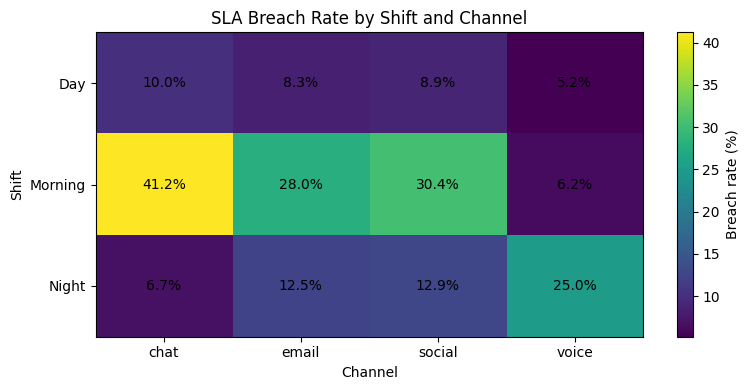

In [188]:
plt.figure(figsize=(8, 4))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Channel")
plt.ylabel("Shift")
plt.title("SLA Breach Rate by Shift and Channel")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        plt.text(j, i, f"{value:.1f}%", ha="center", va="center")

plt.colorbar(label="Breach rate (%)")
plt.tight_layout()
plt.show()

In [168]:
channel_mix = pd.crosstab(
    tier1["shift"],
    tier1["channel"],
    normalize="index"
) * 100

channel_mix.round(2)

channel,chat,email,social,voice
shift,,,,
Day,43.19,28.52,9.72,18.57
Morning,45.79,35.27,9.58,9.36
Night,40.78,43.92,12.16,3.14


**Quantifying the Channel-Mix effect**

A simple standardization calculation to check "If Morning had its current channel mix, but each channel performed at the overall channel breach rate, what would Morning's breach rate be"

In [169]:
overall_channel_rate = (
    tier1.groupby("channel")["breach"].mean()
)

morning_mix = (
    tier1[tier1["shift"] == "Morning"]["channel"]
    .value_counts(normalize=True)
)

expected_morning_rate = (
    morning_mix * overall_channel_rate
).sum()

actual_morning_rate = (
    tier1[tier1["shift"] == "Morning"]["breach"].mean()
)

print("Actual:", actual_morning_rate)
print("Expected from channel mix:", expected_morning_rate)

Actual: 0.32246904588492353
Expected from channel mix: 0.22365328129383275


**Weekly Dimension**

In [159]:
tickets_clean["report_week"] = (
    tickets_clean["created_at_ist"].dt.isocalendar().week
)

In [160]:
tickets_clean["report_week"] = (
    tickets_clean["created_at_ist"].dt.strftime("%G-W%V")
)

In [161]:
tickets_clean['report_week'][:5]

0    2025-W01
1    2025-W01
2    2025-W01
3    2025-W01
4    2025-W01
Name: report_week, dtype: str

**Weekly Shift Analysis**

In [170]:
tier1["report_week"] = (
    tier1["created_at_ist"]
    .dt.strftime("%G-W%V")
)

In [171]:
weekly_shift = (
    tier1
    .groupby(["report_week", "shift"])
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

weekly_shift["breach_rate"] *= 100

weekly_shift.head(15)

tickets  breaches  breach_rate
report_week shift                                  
2025-W01    Day           10         0     0.000000
            Morning       12         0     0.000000
            Night          4         0     0.000000
2025-W02    Day           19         1     5.263158
            Morning       16         0     0.000000
            Night          9         2    22.222222
2025-W03    Day           25         3    12.000000
            Morning       20         2    10.000000
            Night          7         1    14.285714
2025-W04    Day           33         1     3.030303
            Morning       27         4    14.814815
            Night         12         2    16.666667
2025-W05    Day           25         1     4.000000
            Morning       31         4    12.903226
            Night          9         1    11.111111

**Weekly Overall SLA**

In [ ]:
weekly_summary = (
    tickets_clean
    .groupby("report_week")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

weekly_summary["breach_rate"] *= 100

weekly_summary.head()

,tickets,breaches,breach_rate
report_week,,,
2025-W01,31,0,0.000000
2025-W02,50,3,6.000000
2025-W03,58,8,13.793103
2025-W04,80,7,8.750000
2025-W05,72,6,8.333333


In [ ]:
weekly_summary.tail()

,tickets,breaches,breach_rate
report_week,,,
2026-W23,162,36,22.222222
2026-W24,163,47,28.834356
2026-W25,195,46,23.589744
2026-W26,207,49,23.671498
2026-W27,31,3,9.677419


**Weekly SLA line chart**

We add a 4-week rolling average to smooth out the interval for plotting

In [191]:
weekly_summary = weekly_summary.sort_index()

weekly_summary["rolling_4wk"] = (
    weekly_summary["breach_rate"]
    .rolling(4)
    .mean()
)

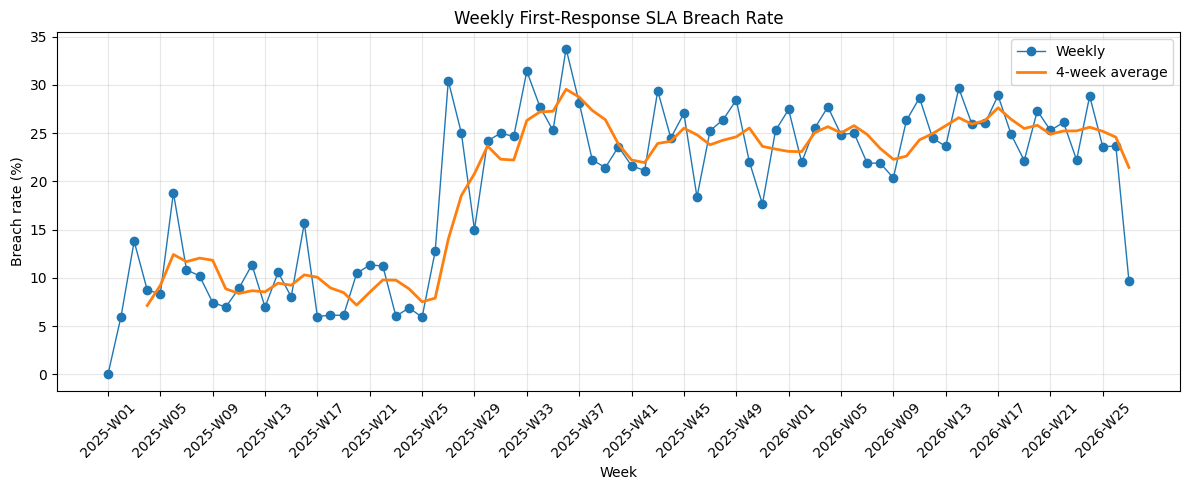

In [192]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_summary.index,
    weekly_summary["breach_rate"],
    marker="o",
    linewidth=1,
    label="Weekly"
)

plt.plot(
    weekly_summary.index,
    weekly_summary["rolling_4wk"],
    linewidth=2,
    label="4-week average"
)

plt.xlabel("Week")
plt.ylabel("Breach rate (%)")
plt.title("Weekly First-Response SLA Breach Rate")
plt.xticks(
    range(0, len(weekly_summary), 4),
    weekly_summary.index[::4],
    rotation=45
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Agents Analysis**

In [184]:
agent_summary = (
    tier1
    .groupby("agent_id")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
    .reset_index()
)

agent_summary["breach_rate"] *= 100

In [185]:
agent_shift = (
    tier1[["agent_id", "shift"]]
    .drop_duplicates("agent_id")
)

agent_summary = agent_summary.merge(
    agent_shift,
    on="agent_id",
    how="left"
)

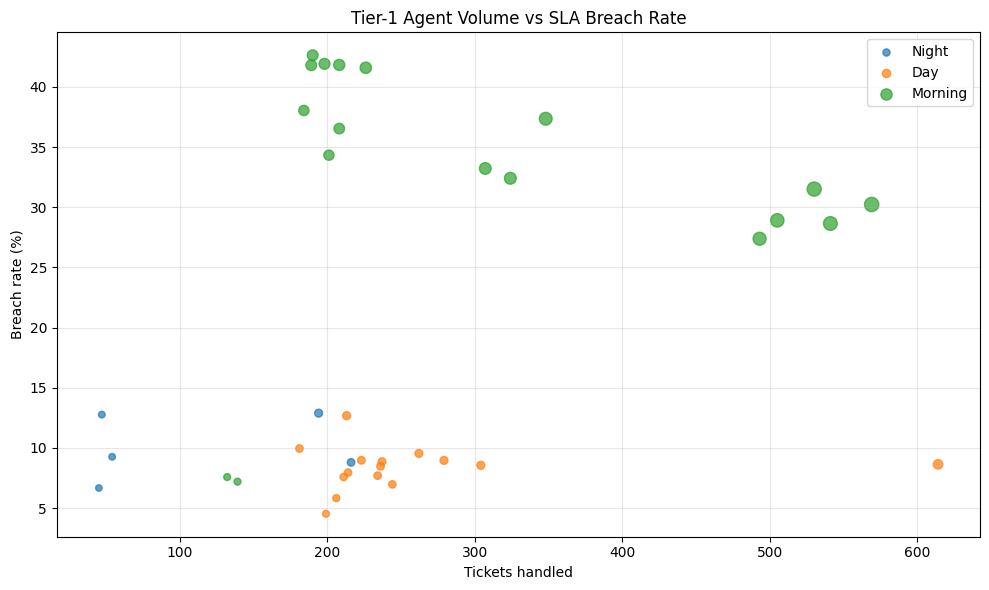

In [181]:
plt.figure(figsize=(10, 6))

for shift_name in agent_summary["shift"].unique():
    subset = agent_summary[
        agent_summary["shift"] == shift_name
    ]

    plt.scatter(
        subset["tickets"],
        subset["breach_rate"],
        s=subset["breaches"] / 2 + 20,
        label=shift_name,
        alpha=0.7
    )

plt.xlabel("Tickets handled")
plt.ylabel("Breach rate (%)")
plt.title("Tier-1 Agent Volume vs SLA Breach Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We essentially have three clusters:

* Morning → roughly 27–43%
* Day     → roughly 4–13%
* Night   → roughly 7–14%*

So the variation is much more strongly aligned with shift than with individual agents.

The morning shift usually spikes across all channels. But we need tio study if that's the problem with the shift itself..

Let's see whether Morning's problem exists across the different teams.

In [189]:
team_shift = (
    tier1
    .groupby(["shift", "team"])
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
    .reset_index()
)

team_shift["breach_rate"] *= 100

team_shift.sort_values(
    ["shift", "tickets"],
    ascending=[True, False]
)

,shift,team,tickets,breaches,breach_rate
1,Day,Chat Frontline,1163,103,8.856406
3,Day,Logistics,845,76,8.994083
2,Day,Email Frontline,681,54,7.929515
0,Day,Billing,614,53,8.631922
4,Day,Returns Desk,450,48,10.666667
5,Day,Voice Frontline,405,21,5.185185
7,Morning,Chat Frontline,1604,639,39.837905
9,Morning,Logistics,1071,322,30.065359
8,Morning,Email Frontline,998,281,28.156313
6,Morning,Billing,979,337,34.422880


In [190]:
team_shift[
    team_shift["shift"] == "Morning"
].sort_values("tickets", ascending=False)

,shift,team,tickets,breaches,breach_rate
7,Morning,Chat Frontline,1604,639,39.837905
9,Morning,Logistics,1071,322,30.065359
8,Morning,Email Frontline,998,281,28.156313
6,Morning,Billing,979,337,34.422880
10,Morning,Returns Desk,569,172,30.228471
11,Morning,Voice Frontline,271,20,7.380074


**Comparative Study of Agents across Channels**

In [182]:
agent_shift_summary = (
    tier1
    .groupby(["shift", "agent_id"])
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
    .reset_index()
)

agent_shift_summary["breach_rate"] *= 100

In [183]:
agent_shift_summary.sort_values(
    ["shift", "tickets"],
    ascending=[True, False]
)

,shift,agent_id,tickets,breaches,breach_rate
14,Day,A3034,614,53,8.631922
11,Day,A3027,304,26,8.552632
12,Day,A3029,279,25,8.960573
13,Day,A3030,262,25,9.541985
7,Day,A3021,244,17,6.967213
16,Day,A3038,237,21,8.860759
4,Day,A3012,236,20,8.474576
3,Day,A3006,234,18,7.692308
8,Day,A3022,223,20,8.968610
6,Day,A3020,214,17,7.943925


**To rank Agents we shall inspect [volume + breach count + breach rate + shift]**

Channel mix alone doesn't explain it

What Does is 
1. Team
2. Load
3. Timing


In [193]:
tier1["created_hour"] = (
    tier1["created_at_ist"].dt.hour
)

hourly = (
    tier1
    .groupby("created_hour")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

hourly["breach_rate"] *= 100

hourly

,tickets,breaches,breach_rate
created_hour,,,
0,261,149,57.088123
1,177,102,57.627119
2,122,57,46.721311
3,105,44,41.904762
4,103,47,45.631068
5,134,51,38.059701
6,141,14,9.929078
7,214,28,13.084112
8,350,36,10.285714


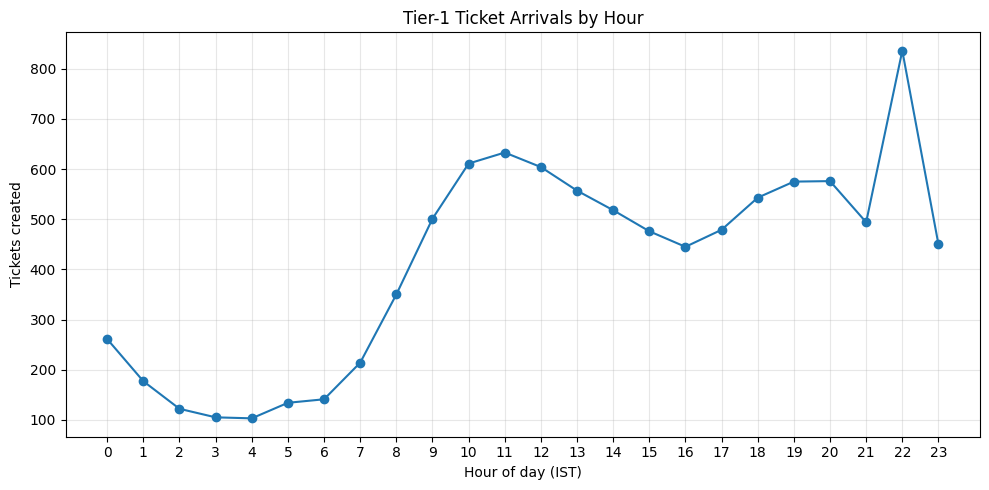

In [194]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly.index,
    hourly["tickets"],
    marker="o"
)

plt.xlabel("Hour of day (IST)")
plt.ylabel("Tickets created")
plt.title("Tier-1 Ticket Arrivals by Hour")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot shows us ticket arrival distribution. But ticket arrivals ≠ workload on a shift.

Why?

A ticket created at 05:59 may be handled later.

A ticket created at 22:30 may be picked up by Night or subsequently Morning.

So let's explicitly derive arrival shift.

In [195]:
def get_shift(hour):
    if 6 <= hour < 14:
        return "Morning"
    elif 14 <= hour < 22:
        return "Day"
    else:
        return "Night"

In [196]:
tier1["arrival_hour"] = tier1["created_at_ist"].dt.hour

tier1["arrival_shift"] = (
    tier1["arrival_hour"].apply(get_shift)
)

In [197]:
tier1["arrival_shift"].value_counts()

arrival_shift
Day        4106
Morning    3611
Night      2188
Name: count, dtype: int64

In [198]:
shift_flow = pd.crosstab(
    tier1["arrival_shift"],
    tier1["shift"]
)

shift_flow

shift,Day,Morning,Night
arrival_shift,,,
Day,3324,706,76
Morning,764,2841,6
Night,70,1945,173


In [199]:
shift_flow_pct = pd.crosstab(
    tier1["arrival_shift"],
    tier1["shift"],
    normalize="index"
) * 100

shift_flow_pct.round(2)

shift,Day,Morning,Night
arrival_shift,,,
Day,80.95,17.19,1.85
Morning,21.16,78.68,0.17
Night,3.20,88.89,7.91


*The policy explicitly says queues outside staffed hours move to the next shift in creation order.*

This indicates how subsequent shifts inherits past shift workload, besides just accounting for arrival_hour for tickets, we also consider the arrival_shift

In [200]:
flow_breach = (
    tier1
    .groupby(["arrival_shift", "shift"])
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
    .reset_index()
)

flow_breach["breach_rate"] *= 100

flow_breach

,arrival_shift,shift,tickets,breaches,breach_rate
0,Day,Day,3324,181,5.445247
1,Day,Morning,706,172,24.362606
2,Day,Night,76,14,18.421053
3,Morning,Day,764,124,16.230366
4,Morning,Morning,2841,218,7.673354
5,Morning,Night,6,6,100.000000
6,Night,Day,70,50,71.428571
7,Night,Morning,1945,1381,71.002571
8,Night,Night,173,7,4.046243


**When is a ticket most likely to breach ?**

In [201]:
hourly_risk = (
    tier1
    .groupby("arrival_hour")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean"),
        median_response=("response_minutes", "median")
    )
)

hourly_risk["breach_rate"] *= 100

hourly_risk.round(2)

,tickets,breaches,breach_rate,median_response
arrival_hour,,,,
0,261,149,57.09,373.0
1,177,102,57.63,314.0
2,122,57,46.72,256.0
3,105,44,41.90,212.0
4,103,47,45.63,143.0
5,134,51,38.06,87.0
6,141,14,9.93,36.0
7,214,28,13.08,24.0
8,350,36,10.29,29.0


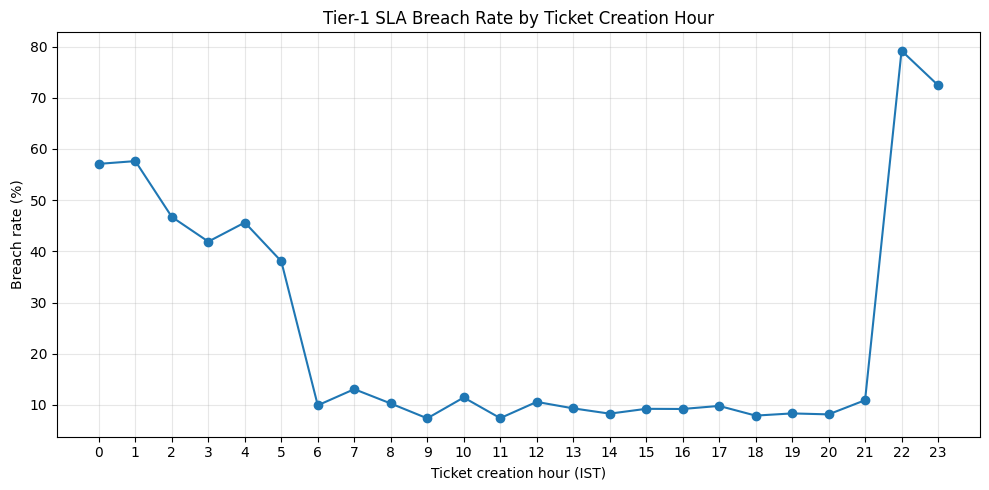

In [202]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_risk.index,
    hourly_risk["breach_rate"],
    marker="o"
)

plt.xlabel("Ticket creation hour (IST)")
plt.ylabel("Breach rate (%)")
plt.title("Tier-1 SLA Breach Rate by Ticket Creation Hour")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

There is a very sharp discontinuity around the Night-period boundary.

It's much stronger evident that: The raw problem appears to be concentrated in tickets created during the late-night/overnight period that gets inherited by Morning shift.

Now we combine LOAD + RISK

Now we think about every hour as:

$$ \text{Load} = \text{tickets created} $$ $$ \text{Risk} = \text{breach rate} $$

A dangerous operating period is:

HIGH LOAD + HIGH BREACH RATE

Not simply: HIGH BREACH RATE

because an hour with 5 tickets and 3 breaches isn't operationally equivalent to an hour with 500 tickets and 200 breaches.

In [203]:
hourly_risk["tickets"] = hourly_risk["tickets"].astype(int)

hourly_risk.round(2)

,tickets,breaches,breach_rate,median_response
arrival_hour,,,,
0,261,149,57.09,373.0
1,177,102,57.63,314.0
2,122,57,46.72,256.0
3,105,44,41.90,212.0
4,103,47,45.63,143.0
5,134,51,38.06,87.0
6,141,14,9.93,36.0
7,214,28,13.08,24.0
8,350,36,10.29,29.0


In [204]:
agent_summary = (
    tier1
    .groupby(["shift", "agent_id"])
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
    .reset_index()
)

agent_summary["breach_rate"] *= 100

Now calculate each agent's contribution for their shift's breaches:

= agent_breaches/ total_breaches in that shift

In [205]:
shift_breach_totals = (
    agent_summary
    .groupby("shift")["breaches"]
    .transform("sum")
)

agent_summary["shift_breach_share"] = (
    agent_summary["breaches"]
    / shift_breach_totals
    * 100
)

In [206]:
agent_summary.sort_values(
    ["shift", "breaches"],
    ascending=[True, False]
)

,shift,agent_id,tickets,breaches,breach_rate,shift_breach_share
14,Day,A3034,614,53,8.631922,14.929577
15,Day,A3036,213,27,12.676056,7.605634
11,Day,A3027,304,26,8.552632,7.323944
12,Day,A3029,279,25,8.960573,7.042254
13,Day,A3030,262,25,9.541985,7.042254
16,Day,A3038,237,21,8.860759,5.915493
4,Day,A3012,236,20,8.474576,5.633803
8,Day,A3022,223,20,8.968610,5.633803
1,Day,A3003,142,18,12.676056,5.070423
3,Day,A3006,234,18,7.692308,5.070423


**Same Shift Cases**

| Arrival → Resolver  | Breach rate |
| ------------------- | ----------: |
| Morning → Morning   |   **7.67%** |
| Day → Day           |   **5.45%** |
| Night → Night       |   **4.05%** |
| **Night → Morning** |  **71.00%** |
| Day → Morning       |      24.36% |


**Cross Shift Cases**

| Ticket created during | Resolved by Morning |  Breaches | Breach rate |
| --------------------- | ------------------: | --------: | ----------: |
| Morning               |               2,841 |       218 |   **7.67%** |
| Day                   |                 706 |       172 |  **24.36%** |
| **Night**             |           **1,945** | **1,381** |  **71.00%** |


The observations clearly states that the Morning problem is probably inherited backlog

And:

$$ \frac{1945}{2188}=88.89\% $$

So 88.9% of Night-created Tier-1 tickets end up attributed to a Morning resolver.

More strikingly:

$$ \frac{1381}{2153}\approx64.1\% $$

So roughly 64% of all Tier-1 breaches are Night-created tickets ultimately attributed to Morning resolvers.

And:

$$ \frac{1381}{1771}\approx78.0\% $$

So roughly 78% of Morning-attributed breaches come from tickets created during the Night window.


Observing the Night arrival effect sharpply

In [207]:
arrival_summary = (
    tier1
    .groupby("arrival_shift")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

arrival_summary["breach_rate"] *= 100

arrival_summary

,tickets,breaches,breach_rate
arrival_shift,,,
Day,4106,367,8.938139
Morning,3611,348,9.637220
Night,2188,1438,65.722121


Night arrival by channel

In [208]:
night_channel = (
    tier1[tier1["arrival_shift"] == "Night"]
    .groupby("channel")
    .agg(
        tickets=("ticket_id", "count"),
        breaches=("breach", "sum"),
        breach_rate=("breach", "mean")
    )
)

night_channel["breach_rate"] *= 100

night_channel.sort_values(
    "breach_rate",
    ascending=False
)

,tickets,breaches,breach_rate
channel,,,
chat,1138,940,82.601054
social,184,128,69.565217
email,866,370,42.725173


In [209]:
night_flow = (
    flow_breach[
        flow_breach["arrival_shift"] == "Night"
    ]
    .sort_values("tickets", ascending=False)
)

night_flow

,arrival_shift,shift,tickets,breaches,breach_rate
7,Night,Morning,1945,1381,71.002571
8,Night,Night,173,7,4.046243
6,Night,Day,70,50,71.428571


In [210]:
night_morning = night_flow[
    night_flow["shift"] == "Morning"
].iloc[0]

total_tier1_breaches = tier1["breach"].sum()

print(
    "Share of all Tier-1 breaches:",
    night_morning["breaches"] / total_tier1_breaches * 100
)

Share of all Tier-1 breaches: 64.14305620065025


In [211]:
morning_tickets = tier1[tier1["shift"] == "Morning"]

night_inherited = (
    morning_tickets["arrival_shift"] == "Night"
).sum()

print(night_inherited)
print(night_inherited / len(morning_tickets) * 100)

1945
35.41514930808449


In [215]:
morning = tier1[tier1["shift"] == "Morning"]

(
    morning["arrival_shift"].value_counts(),
    morning["arrival_shift"].value_counts(normalize=True) * 100
)

(arrival_shift
 Morning    2841
 Night      1945
 Day         706
 Name: count, dtype: int64,
 arrival_shift
 Morning    51.729789
 Night      35.415149
 Day        12.855062
 Name: proportion, dtype: float64)

So about 35% of Morning-attributed Tier-1 tickets were created during Night.

Key Financial Impact: What portion of that breach exposure is associated with the Night → Morning flow, and what reduction is operationally plausible?

In [213]:
# Tier 1 branch rate
tier1["breach"].mean()

np.float64(0.21736496718828874)

In [214]:
# Night-induced breach rate
tier1[
    tier1["arrival_shift"] == "Night"
]["breach"].mean()

np.float64(0.6572212065813529)

**What shift actually gave the first response?**

In [216]:
tier1["response_hour"] = tier1["first_response_at_ist"].dt.hour

tier1["response_shift"] = tier1["response_hour"].apply(get_shift)

In [217]:
response_flow = pd.crosstab(
    tier1["arrival_shift"],
    tier1["response_shift"]
)

response_flow

response_shift,Day,Morning,Night
arrival_shift,,,
Day,3398,59,649
Morning,692,2855,64
Night,5,1820,363


In [218]:
response_flow_pct = pd.crosstab(
    tier1["arrival_shift"],
    tier1["response_shift"],
    normalize="index"
) * 100

response_flow_pct.round(2)

response_shift,Day,Morning,Night
arrival_shift,,,
Day,82.76,1.44,15.81
Morning,19.16,79.06,1.77
Night,0.23,83.18,16.59


We compare and quantify night window V/s non-night window

In [219]:
night_window = tier1[
    tier1["arrival_shift"] == "Night"
]

night_window["breach"].agg(["count", "sum", "mean"])

count    2188.000000
sum      1438.000000
mean        0.657221
Name: breach, dtype: float64

In [220]:
non_night = tier1[
    tier1["arrival_shift"] != "Night"
]

non_night["breach"].agg(["count", "sum", "mean"])

count    7717.000000
sum       715.000000
mean        0.092653
Name: breach, dtype: float64

**Business impact on resiolved/closed tickets**

In [221]:
realized = tickets_clean[
    tickets_clean["breach"] &
    tickets_clean["status"].isin(["resolved", "closed"])
]

realized_breaches = len(realized)

realized_credits = realized_breaches * 350

realized_breaches, realized_credits

(2320, 812000)

In [222]:
weekly_volume = 650
weeks_per_quarter = 13
credit_per_breach = 350

observed_weekly_rate = tier1["breach"].mean()

projected_quarterly_credits = (
    weekly_volume
    * weeks_per_quarter
    * observed_weekly_rate
    * credit_per_breach
)

projected_quarterly_credits

np.float64(642856.8904593639)

#### Validation/ Error-Analysis

In [224]:
checks = {
    "unique_ticket_id":
        tickets_clean["ticket_id"].is_unique,

    "no_negative_response":
        (tickets_clean["response_minutes"] >= 0).all(),

    "all_channels_have_sla":
        tickets_clean["sla_target_minutes"].notna().all(),

    "valid_breach_values":
        tickets_clean["breach"].isin([True, False]).all(),

    "all_completed_have_one_roster":
        (match_counts == 1).all(),
}

pd.Series(checks)

unique_ticket_id                 True
no_negative_response             True
all_channels_have_sla            True
valid_breach_values              True
all_completed_have_one_roster    True
dtype: bool

In [225]:
tickets_clean["breach"].mean()

np.float64(0.21785714285714286)

In [226]:
independent_target = tickets_clean["channel"].map({
    "chat": 15,
    "voice": 120,
    "social": 240,
    "email": 480
})

independent_breach = (
    tickets_clean["response_minutes"] >
    independent_target
)

(independent_breach == tickets_clean["breach"]).value_counts()

True    11200
Name: count, dtype: int64

In [227]:
(independent_breach != tickets_clean["breach"]).sum()

np.int64(0)

**This gives us 0/11,200 determninistic SLA discrepancies**

In [228]:
test = pd.DataFrame({
    "channel": [
        "chat", "chat", "chat",
        "email", "email", "email"
    ],
    "response_minutes": [
        14, 15, 16,
        479, 480, 481
    ]
})

test["sla"] = test["channel"].map({
    "chat": 15,
    "email": 480
})

test["breach"] = (
    test["response_minutes"] > test["sla"]
)

test

,channel,response_minutes,sla,breach
0,chat,14,15,False
1,chat,15,15,False
2,chat,16,15,True
3,email,479,480,False
4,email,480,480,False
5,email,481,480,True


In [229]:
completed_time_check = (
    tier1["first_response_at_ist"] <=
    tier1["resolved_at_ist"]
)

completed_time_check.value_counts()

True    9905
Name: count, dtype: int64

32 ticket stratified review - 8 from each channel

In [231]:
sample = (
    tickets_clean
    .groupby("channel", group_keys=False)
    .sample(n=8, random_state=42)
)

sample[
    [
        "ticket_id",
        "channel",
        "created_at_ist",
        "first_response_at_ist",
        "response_minutes",
        "sla_target_minutes",
        "breach"
    ]
]

,ticket_id,channel,created_at_ist,first_response_at_ist,response_minutes,sla_target_minutes,breach
7051,TK-248889,chat,2026-01-14 00:25:00+05:30,2026-01-14 06:22:00+05:30,357.0,15,True
4985,TK-246277,chat,2025-11-01 15:24:00+05:30,2025-11-01 15:37:00+05:30,13.0,15,False
2890,TK-243643,chat,2025-08-08 16:58:00+05:30,2025-08-08 17:00:00+05:30,2.0,15,False
6567,TK-248290,chat,2025-12-27 20:18:00+05:30,2025-12-27 20:21:00+05:30,3.0,15,False
352,TK-240450,chat,2025-02-07 23:02:00+05:30,2025-02-07 23:14:00+05:30,12.0,15,False
2494,TK-243143,chat,2025-07-17 20:57:00+05:30,2025-07-17 21:00:00+05:30,3.0,15,False
10224,TK-252877,chat,2026-05-22 14:41:00+05:30,2026-05-22 14:49:00+05:30,8.0,15,False
9651,TK-252170,chat,2026-04-29 09:05:00+05:30,2026-04-29 09:09:00+05:30,4.0,15,False
8698,TK-250985,email,2026-03-21 02:49:00+05:30,2026-03-21 08:23:00+05:30,334.0,480,False
3285,TK-244153,email,2025-08-26 18:35:00+05:30,2025-08-26 22:01:00+05:30,206.0,480,False


**The SLA problem is strongly concentrated in tickets created during the Night window, with a large share subsequently receiving their first response during Morning. Channel mix does not explain the Morning gap by itself. This makes overnight queue/handoff handling the primary operational area to investigate, while agent-level breach rates should not be interpreted as proof of individual causation because the export lacks complete queue-event history.**